<a href="https://colab.research.google.com/github/novalrnv/machine_learning/blob/main/JS06/JS06-02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2 - Klasifikasi SVM dengan Data Dummy Non-Linier

Mengikuti langkah-langkah pada modul JS06 - Klasifikasi 2, Lab 2.

Dengan *kernel trick*, SVM mampu membuat decision boundary pada data non-linier.

## Langkah 1 - Ilustrasi Data Non-Linier

### Langkah 1a - Import Library

In [97]:
# import library
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from sklearn.svm import SVC

### Langkah 1b - Buat Kembali Fungsi Plotting

In [98]:
# buat sebuah fungsi untuk menampilkan fitting data

def plot_svc_decision_function(model, ax=None, plot_support=True):

    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # buat grid untuk evaluasi model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # plot batas dan margin
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

### Langkah 1c - Buat Data Dummy Non-Linier

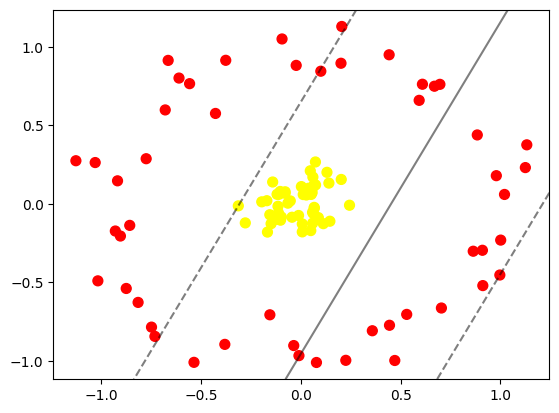

In [125]:
# contoh data tidak terpisah secara linier
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

clf = SVC(kernel='linear').fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf, plot_support=False);

Tidak ditemukan garis pemisah linier yang mampu memisahkan data. Oleh karena itu diperlukan proyeksi lain terhadap data. Proyeksi yang digunakan adalah proyeksi berbasis radial:

$$r = e^{-(x_1^2 + x_2^2)}$$

In [126]:
r = np.exp(-(X**2).sum(1))

Karena proyeksi radial tidak cukup menggunakan model 2D, maka plot visualisasi diubah menjadi model 3D.

In [127]:
from mpl_toolkits import mplot3d
from ipywidgets import interact, fixed

def plot_3D(elev=30, azim=30, X=X, y=y):
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap='autumn')
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('r')

interact(plot_3D, elev=[-90, 45, 30, 20 , 10], azim=(-180, 180),
         X=fixed(X), y=fixed(y))

interactive(children=(Dropdown(description='elev', index=2, options=(-90, 45, 30, 20, 10), value=30), IntSlide…

<function __main__.plot_3D(elev=30, azim=30, X=array([[ 0.0733803 ,  0.26675257],
       [-0.16998634,  0.02004407],
       [-0.1031541 ,  0.07887835],
       [ 0.00295105,  0.10998006],
       [ 0.70467057, -0.66353633],
       [-0.10963483,  0.06076234],
       [ 0.20140044,  0.89563905],
       [-0.00924072, -0.96680624],
       [-0.04391479, -0.08522398],
       [-0.09721506, -0.0841008 ],
       [-0.14094766,  0.1391731 ],
       [ 0.06719109, -0.02247253],
       [ 0.06779181, -0.02785642],
       [ 0.35849699, -0.80835467],
       [-0.73098525, -0.84418538],
       [-0.92937336, -0.17307992],
       [ 0.66966986,  0.74926451],
       [-0.67931977,  0.59826073],
       [ 0.13114008,  0.20092002],
       [ 0.44453975, -0.77341883],
       [ 0.00738224, -0.17855087],
       [-0.38064521, -0.89513662],
       [ 0.05009221, -0.17035384],
       [-0.15495363, -0.70671012],
       [ 0.05933672, -0.12339972],
       [ 0.6095092 ,  0.76193554],
       [ 0.06273534, -0.0614647 ],
       [-0.12064461, -0.08818428],
       [ 0.44273067,  0.94961619],
       [ 1.13257719,  0.37597869],
       [ 0.53076969, -0.70421032],
       [ 0.00757106, -0.12796401],
       [ 0.8844062 ,  0.43894307],
       [-0.91834387,  0.14667425],
       [ 0.05679296,  0.07141875],
       [ 0.69708346,  0.76130983],
       [-0.31312591, -0.01264252],
       [ 0.0391403 ,  0.09936038],
       [-0.90389476, -0.20501182],
       [ 0.07398688,  0.12054242],
       [-0.81529208, -0.62779896],
       [ 0.07846461, -1.01046663],
       [-0.03532534, -0.90268005],
       [ 0.20273702,  0.15538341],
       [ 0.2442143 , -0.00877697],
       [ 0.05898709, -0.05357147],
       [-0.27806477, -0.12135534],
       [-0.10150258, -0.10403915],
       [-0.11200467, -0.05723339],
       [ 0.06058058,  0.17052132],
       [ 0.14085712,  0.13221616],
       [ 0.10034681,  0.84490693],
       [ 0.97983148,  0.17949934],
       [ 0.05208718,  0.06013788],
       [-0.77479965,  0.28749712],
       [-0.15524975, -0.06922766],
       [-0.37605859,  0.91440548],
       [-1.01688449, -0.49044878],
       [-0.14886018, -0.12632137],
       [ 0.01225395,  0.05921825],
       [-0.01117537, -0.07403622],
       [ 0.91017273, -0.29573483],
       [-0.55721896,  0.76561116],
       [-0.114274  , -0.01532446],
       [ 0.05627459,  0.09322327],
       [-0.87469415, -0.5390252 ],
       [-0.09396334,  1.05035396],
       [ 0.04754671,  0.21052614],
       [-0.85715481, -0.13712254],
       [-0.16697728, -0.1798485 ],
       [ 0.11293839, -0.12624628],
       [ 0.47105813, -0.99778427],
       [ 0.59318956,  0.65933619],
       [-0.06476547,  0.00434491],
       [ 1.0017841 , -0.23093241],
       [ 0.20544656,  1.12986534],
       [ 1.12532388,  0.2310303 ],
       [-0.11889091,  0.0608652 ],
       [-0.07822445,  0.07684824],
       [ 0.91216809, -0.52073407],
       [-0.07861057,  0.06713865],
       [-0.12418094, -0.09876907],
       [-1.0302759 ,  0.26308174],
       [ 0.02782031,  0.05635097],
       [-0.66464701,  0.91382615],
       [ 0.86412014, -0.301799  ],
       [ 0.22558897, -0.99672457],
       [-0.02304068,  0.8820428 ],
       [ 0.99747253, -0.45330387],
       [ 0.06466259,  0.11670739],
       [-0.42741544,  0.57587768],
       [-0.61026892,  0.8012779 ],
       [ 0.14580121, -0.11059588],
       [ 0.08795117, -0.08777053],
       [-0.19560793,  0.0129038 ],
       [-0.05276572,  0.01888516],
       [ 1.02087574,  0.05984006],
       [-0.53516411, -1.0095807 ],
       [-1.12699219,  0.27464012],
       [-0.74807889, -0.78522852]]), y=array([1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0]))>

Pada tampilan 3D, kedua kelas dapat dipisahkan dengan sebuah bidang pada ketinggian `r` tertentu.

## Langkah 2 - Fitting Model

Memproyeksikan N titik data ke dimensi yang lebih tinggi menambah beban komputasi. Untuk mengatasinya, digunakan kernel *radial basis function* (RBF) pada Scikit-Learn.

In [128]:
clf = SVC(kernel='rbf', C=1E6)
clf.fit(X, y)

SVC(C=1000000.0)

Plot decision boundary dari kernel RBF.

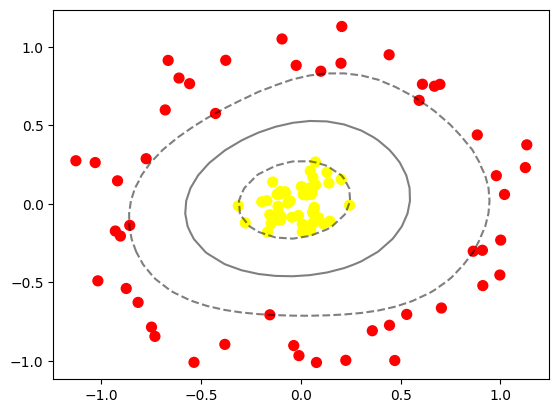

In [129]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
	          s=300, lw=1, facecolors='none')